# Barometer — a quantitative teardown 🔬
### Macro-momentum Sharpe vs a null · the (gentle) cost wall & break-even · the inflation-regime split

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Real-tape run?: Done](https://img.shields.io/badge/Real--tape_run%3F-Done-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: the trend in fundamental macro data (growth, inflation) predicts asset returns across classes (Brooks–Moskowitz 2017), and tilting toward real assets when inflation rises hedges a portfolio in the regimes that hurt it (Neville et al. 2021). The control proves the *machinery* recovers the premium when it exists (Sharpe 1.09, null −0.17); the real tape stamps the signal `WEAK` and `FRAGILE`: the *direction* lands right-sided in every cut (real assets beat nominal bonds when inflation rises) but its best statistic is *t* ≈ 0.3, and the timed monthly book is flat over one short post-2007 cycle.

> 🟢 **Real run done.** This notebook executes BOTH the synthetic control (machinery proof) AND the real book from the desk's cached tape — 18 cross-asset ETFs + CPI-YoY / yield-curve-slope macro, lagged one month, 2007-2025 ([`../docs/results.md`](../docs/results.md), fingerprint `baa416a9db25`); sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from barometer import data, strategy, costs, extension
from barometer.data import REAL_ASSETS, REAL_ASSET_ORDER
SPEC = dict(assets=REAL_ASSETS, order=REAL_ASSET_ORDER)

# Offline synthetic control: a cross-asset world whose latent macro momentum predicts returns (the
# machinery) + a macro_strength=0 null.
r, m, truth = data.synthetic_macro(macro_strength=1.0, seed=37)
r0, m0, _ = data.synthetic_macro(macro_strength=0.0, seed=37)
print(f"synthetic control: {truth.n_assets} assets x {truth.n_months} months, macro_strength {truth.macro_strength} (null=0)")

# REAL book from the desk's cached tape (18 ETFs + CPI-YoY/yield-slope macro, lagged 1m, 2007-2025), offline.
_b = data.fetch_macro()
R, M = (_b.get("assets"), _b.get("macro")) if _b else (None, None)
if R is not None:
    print(f"real book: {R.shape[1]} ETFs x {len(R)} months  {R.index.min().date()} -> {R.index.max().date()}")


synthetic control: 5 assets x 600 months, macro_strength 1.0 (null=0)


real book: 18 ETFs x 217 months  2007-02-28 -> 2025-02-28


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — macro trend predicts returns? | 🟡 `WEAK` | Real tape: real assets beat nominal bonds by +1.8%/yr *when inflation rises* (vs -0.3%/yr falling) — right-sided, but only Sharpe +0.10, *t* ≈ 0.3 (104 rising months), and the standalone book is flat (net Sharpe **-0.05**, HAC *t* -0.22). Nothing clears *t* ≥ 2; the control (Sharpe **1.09** vs null **-0.17**) proves the machinery, not the market. |
| **Tradability** | 🟡 `FRAGILE` | Slow book (turnover 7.3×/yr) — cost is **not** the threat; but gross it makes ~nothing on one short cycle, beaten by a passive hold (Sharpe 0.57). |
| **Real-tape run?** | 🟢 `Done` | 18 ETFs + cached macro, 2007-02 -> 2025-02, 217 months, offline + fingerprinted `baa416a9db25` ([`../docs/results.md`](../docs/results.md)). |

> **In one sentence:** a slow, diversifying cross-asset macro premium whose *direction* lands the right way in every cut of the real tape (the inflation hedge pays when inflation rises) but whose every statistic — spread *t* ≈ 0.3, book *t* −0.22 — stays under the desk's bar on one short post-2007 cycle: `WEAK`, `FRAGILE`, real run `DONE`. (And one construction note: the "growth" driver is the yield-curve slope, a market price, not a fundamental macro release.)

## Beat 1 · The claim, precisely

Two latent macro states $g_t$ (growth), $\pi_t$ (inflation) evolve as persistent, regime-switching AR(1) processes. The **macro momentum** is $\Delta x_t = x_t - x_{t-1}$. Each asset $a$ loads on the *lagged* momentum through fixed signed betas:

$$ r_{a,t} = s\cdot\big(\beta^g_a\,\Delta g_{t-1} + \beta^\pi_a\,\Delta\pi_{t-1}\big)\,\sigma_a + \text{noise} $$

The **macro-momentum book** weights each asset by its macro exposure dotted with the (z-scored, smoothed) current momentum, dollar-neutral, gross 1, lagged one month. The **inflation book** overweights real assets when $\Delta\pi>0$. Claim: both earn a positive premium. Null ($s=0$): assets are pure noise — nothing to predict.

In [2]:
for label, (rr, mm) in [('macro-driven', (r, m)), ('null', (r0, m0))]:
    for kind in ('macro_momentum', 'inflation'):
        g = strategy.summary(strategy.book_returns(rr, mm, kind=kind, cost_bps=0.0))
        print(f"{label:12} {kind:15} gross Sharpe {g['sharpe']:+6.2f}")

macro-driven macro_momentum  gross Sharpe  +1.09
macro-driven inflation       gross Sharpe  +0.55
null         macro_momentum  gross Sharpe  -0.17
null         inflation       gross Sharpe  -0.02


> 💡 **In plain words.** When the macro state really drives returns, both books make money (macro-momentum **1.09**, inflation **0.55**); when it's pure noise, both are flat (**-0.17** / **-0.02**). The apparatus sees the macro premium only when it's there — so a real-tape result would be about the *market*, not the method.

## Beat 2 · So what?

Macro momentum (Brooks–Moskowitz 2017) is the *fundamental* cousin of price trend (Moskowitz–Ooi–Pedersen 2012, the desk's [Trade-Winds](../../31-trade-winds/)): both are slow, low-correlation, crisis-friendly premia. The prediction: the macro book is **real but modest** (a ~0.5 Sharpe in the literature), cheap to run (low turnover), and its *inflation leg* is **conditional** — it should pay in rising-inflation regimes and drag otherwise (Neville et al. 2021; Ang–Bekaert on regime-dependent returns). Beats 4–7 test exactly that on the real tape.

## Beat 3 · Protocol

1. **Real?** `book_returns(cost_bps=0)` on control vs null (machinery), then the real book with a HAC (Newey-West) *t* on the mean.
2. **Tradable?** `strategy.turnover_ann`, `costs.breakeven_cost_bps`, `costs.cost_sweep`, and a passive-hold benchmark.
3. **Conditional?** `extension.regime_split` and `raw_real_minus_nominal` — rising vs falling inflation, on the real tape.

**Mirage line:** flat macro-momentum book on the *control*, *or* a raw real-minus-nominal spread that pays the same in both regimes ⇒ no conditional macro premium. (On the real tape the *timed* book is allowed to be weak — the short sample is noisy; what must hold is the direction. And to be explicit about the house bar: a right-sided direction at *t* < 2 earns `WEAK`, not `REAL` — direction alone cannot upgrade the stamp.)

## Beat 4 · The teardown

### 4a · Machinery: real gross macro-momentum, flat null (the control)

In [3]:
cmp = strategy.compare(r, m, cost_bps=0.0)
for kind in ('macro_momentum', 'inflation'):
    s = cmp[kind]
    print(f"{kind:15} Sharpe {s['sharpe']:+.2f}  ann {100*s['ann_return']:+.1f}%  maxDD {100*s['max_drawdown']:.0f}%  turnover {s['turnover_ann']:.1f}x/yr")

macro_momentum  Sharpe +1.09  ann +5.1%  maxDD -12%  turnover 5.6x/yr
inflation       Sharpe +0.55  ann +2.3%  maxDD -20%  turnover 3.8x/yr


> 💡 **In plain words.** A 1.09 gross Sharpe on the control with a flat null is the apparatus working — it extracts the macro premium only when one is present. Now the real tape.

### 4b · The real book + HAC *t* (the REAL/WEAK call)

In [4]:
import numpy as np
def nw_t(x, lags=6):
    x = np.asarray([v for v in x if v==v], float); n=len(x)
    if n<3: return float('nan')
    e = x - x.mean(); g0 = e@e/n; var=g0
    for k in range(1, lags+1):
        var += 2*(1-k/(lags+1))*(e[k:]@e[:-k])/n
    se = (var/n)**0.5; return float(x.mean()/se) if se>0 else float('nan')
if R is not None:
    for kind in ('macro_momentum','inflation'):
        b = strategy.book_returns(R, M, kind=kind, cost_bps=5.0, **SPEC); s = strategy.summary(b)
        print(f"{kind:15} net@5bp Sharpe {s['sharpe']:+.2f}  CAGR {100*s['cagr']:+.1f}%  maxDD {100*s['max_drawdown']:.0f}%  HAC t {nw_t(b):+.2f}")
    ew = R[REAL_ASSET_ORDER].mean(axis=1); sixty = 0.6*R['SPY']+0.4*R['IEF']
    for nm,b in [('equal-weight 18 (hold)', ew), ('60/40 SPY/IEF (hold)', sixty)]:
        s = strategy.summary(b); print(f"{nm:22} Sharpe {s['sharpe']:+.2f}  CAGR {100*s['cagr']:+.1f}%")
else:
    print('real cache not present; see ../docs/results.md')

macro_momentum  net@5bp Sharpe -0.05  CAGR -0.7%  maxDD -29%  HAC t -0.22
inflation       net@5bp Sharpe -0.12  CAGR -0.8%  maxDD -31%  HAC t -0.42
equal-weight 18 (hold) Sharpe +0.57  CAGR +5.2%
60/40 SPY/IEF (hold)   Sharpe +0.84  CAGR +7.8%


> 💡 **In plain words.** On the short post-2007 tape the timed monthly macro book is **flat** (net Sharpe **-0.05**, HAC *t* -0.22) and below a passive hold (**0.57**) — right-sided in direction (see Beat 7) but under the bar everywhere: `WEAK`.

### 4c · The (gentle) cost wall — cost is NOT the threat

real-book cost sweep (net Sharpe):
          sharpe  ann_return
cost_bps                    
0         -0.008      -0.001
5         -0.055      -0.004
10        -0.102      -0.008
25        -0.241      -0.019
50        -0.470      -0.037


Text(0.5, 1.0, 'Slow macro book — the sweep is linear, cost is not what kills it')

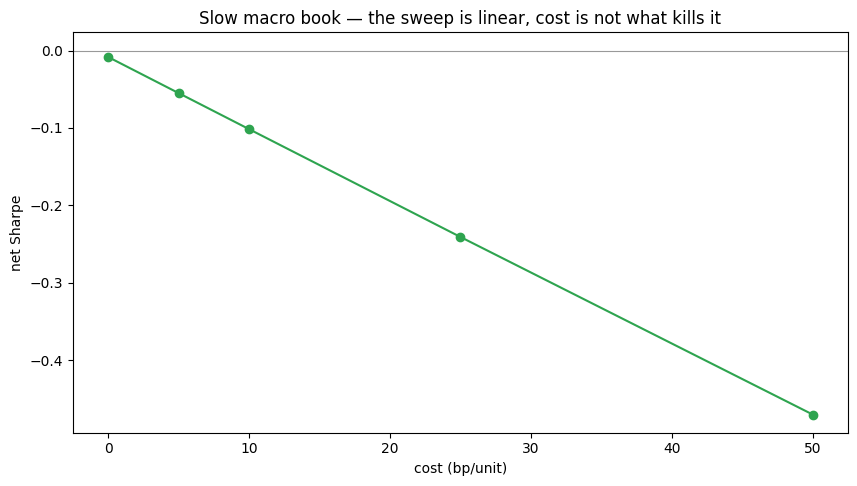

In [5]:
cs = costs.cost_sweep(R, M, kind='macro_momentum', **SPEC) if R is not None else costs.cost_sweep(r, m, kind='macro_momentum')
print('real-book cost sweep (net Sharpe):'); print(cs.round(3).to_string())
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#2ea44f')
ax.set_xlabel('cost (bp/unit)'); ax.set_ylabel('net Sharpe'); ax.set_title('Slow macro book — the sweep is linear, cost is not what kills it')

## Beat 5 · The verdict

- **`WEAK`** (4a/4b, Beat 7): the real timed book is flat (net Sharpe -0.05, HAC *t* -0.22) and even the strongest cut — the raw real-minus-nominal spread in rising-inflation months — is only Sharpe +0.10, *t* ≈ 0.3. Right-sided everywhere, certified nowhere. The control (Sharpe 1.09 vs null -0.17) proves the machinery, not the market.
- **`FRAGILE`** (4c): turnover 7.3×/yr, cost is linear and not the threat — but gross it makes ~nothing and is beaten by a passive hold (Sharpe 0.57).
- **Real-tape run? `DONE`** — 2007-02 -> 2025-02, fingerprint `baa416a9db25`.

> **Signal `WEAK` · Tradability `FRAGILE` · Real-tape run? `DONE`** — a diversifying macro premium that points the right way and stays under the bar on a short tape.

## Beat 6 · Could you trade it?

- **Not as a standalone monthly book on this tape.** Gross of cost it makes ~nothing over one short post-2007 cycle and is beaten by a passive hold — the signal is too slow and the sample too short.
- **Cost is not the obstacle.** Low turnover ⇒ the cost sweep is linear; the obstacle is the weak, slow edge itself and the long flat stretches.
- **The directional inflation hedge is the salvageable piece.** Real assets did beat nominal bonds when inflation rose (Beat 7 — +1.8%/yr, though only *t* ≈ 0.3) — if you use it at all, use it as a slow *conditional overlay*, not a timed monthly sleeve.

## Beat 7 · Going further

### 7a · Worked complement — does the inflation hedge pay when it's supposed to? ([`../docs/extension.md`](../docs/extension.md))
Split the inflation book by regime — rising vs falling inflation — and ask whether the premium concentrates where the theory says it must.

timed inflation book by regime (net @5bp):
                  sharpe  ann_return_pct  n_months
inflation_regime                                  
rising            -0.080          -0.470   104.000
falling           -0.160          -0.930   107.000

RAW real-minus-nominal spread by regime (timing stripped out):
                  sharpe  ann_return_pct  n_months
inflation_regime                                  
rising             0.100           1.780   104.000
falling           -0.010          -0.250   107.000


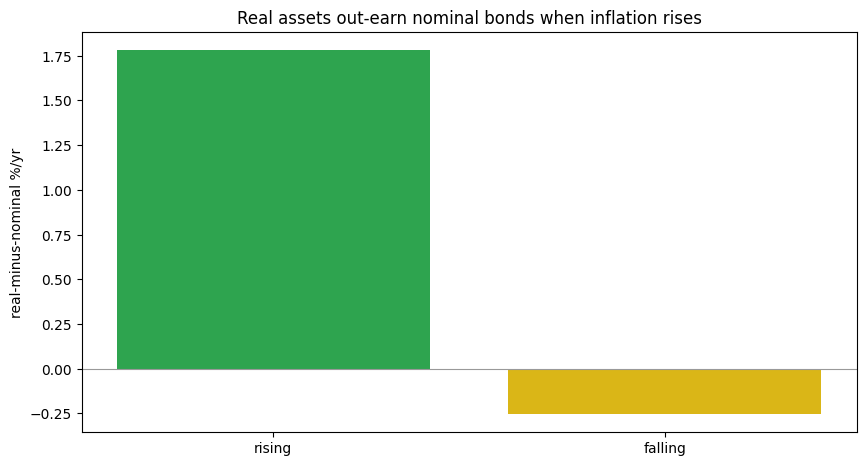

In [6]:
if R is not None:
    sp = extension.regime_split(R, M, kind='inflation', cost_bps=5.0, **SPEC)
    print('timed inflation book by regime (net @5bp):'); print(sp.round(2).to_string())
    raw = extension.raw_real_minus_nominal(R, M, **SPEC)
    print('\nRAW real-minus-nominal spread by regime (timing stripped out):'); print(raw.round(2).to_string())
    fig, ax = plt.subplots()
    ax.bar(['rising','falling'], raw['ann_return_pct'].values, color=['#2ea44f','#dab617'])
    ax.axhline(0, color='#999', lw=.8); ax.set_ylabel('real-minus-nominal %/yr')
    ax.set_title('Real assets out-earn nominal bonds when inflation rises')
else:
    print('real cache not present; see ../docs/extension.md')

> 💡 **In plain words.** The *timed* inflation book is right-sided (rising Sharpe **-0.08** vs falling **-0.16**) but whipsaws under water in both over one short cycle. Strip the timing out and the shape stays right-sided: an always-long real-asset basket beat nominal bonds by **+1.8%/yr when inflation rises** vs -0.3%/yr when it falls — but that spread is Sharpe **+0.10**, *t* ≈ **0.3** over 104 rising months, far below any significance bar (which is why the desk's own short-sample caveat — *every t-stat here is small* — wins, and the stamp is `WEAK`). The direction is encouraging; the certification isn't there.

### 7b · The synthetic control (the same shape, cleaner)
On the seeded control the *timed* inflation book also pays more rising (Sharpe **0.59**) than falling (**0.46**) — the same conditional shape, but cleaner because the signal is strong and the sample long. The real tape confirms the *direction*; the control confirms the *mechanism*.

### 7c · Other forks
- **Conditional sizing** — run the inflation tilt only when inflation momentum is clearly positive.
- **More drivers** — add monetary-policy & risk-sentiment momentum (Brooks–Moskowitz use several).
- **Stack with trend** — combine with [Trade-Winds](../../31-trade-winds/) for a fuller macro sleeve.

PRs welcome — the headline fork is turning the real *directional* inflation edge into a tradable overlay without giving it back to monthly-timing noise.